# PROJET: Clustering et routage dans un essaim de nano-satellites

#### Ayoub Barich, Franck Willy SIMO PIUGIE, Léo Denglos, Damien Lanusse, Mathis Banzet

Voici le texte corrigé :

Les essaims de nano-satellites offrent une solution prometteuse pour des missions spatiales distribuées, mais leur efficacité dépend fortement de la manière dont ils s’organisent en réseau. Le clustering permet de structurer ces satellites en groupes locaux afin de réduire la consommation d’énergie, d’améliorer le débit et de limiter les communications inutiles.

Nous nous plaçons dans le cas d'un essaim de nano-satellites en orbite qui collabore pour collecter et échanger des données scientifiques. Chaque satellite doit transmettre ses données dans un environnement à haute mobilité, à densité variable et avec des liens inter-satellites dynamiques.

Notre principal objectif est de diviser l’essaim en groupes homogènes pour :
- Répartir la charge réseau,
- Optimiser l’énergie,
- Maximiser le débit effectif.

Les principales contraintes sont que nous n'avons pas de coordination centrale. Le clustering peut être fait à des distances variables comme 20, 40 ou 60 km. Pour atténuer la contrainte précédente et en vue de la quantité de données et d'analyses, nous avons fixé la distance à 30 km pour simplifier l'analyse et réduire la quantité de données. Une autre contrainte est que tous les satellites doivent recevoir les données.

Dans ce projet, nous commencerons par une analyse de la dynamique d'un essaim de nano-satellites, puis nous étudierons des algorithmes de clustering que nous appliquerons à des traces simulées de positions de satellites. Chaque méthode est évaluée selon des critères définis avec pour objectif d'identifier l'approche la plus adaptée à un environnement spatial mobile et contraint.

La problématique dégagé est la suivante : 

Comment diviser dynamiquement un essaim en groupes homogènes, distribués et efficaces pour router les données, tout en équilibrant le débit et la consommation énergétique ?

Nous avons aussi dégagé des enjeux techniques et scientifiques de ce problème. 

- Réseaux distribués : Les nano-satellites doivent s'organiser en clusters sans coordination centrale, nécessitant des algorithmes décentralisés.

- Économie d'énergie : Le routage local et groupé réduit la consommation énergétique, prolongeant ainsi la durée de vie des missions.

- Qualité de Service (QoS) : Il est crucial d'équilibrer débit, portée et retransmissions pour maintenir une communication efficace.

- Dynamique spatiale : La mobilité des satellites crée une topologie changeante, exigeant des algorithmes adaptatifs pour une connectivité stable.


## On repartira le traitement en trois principaux objectifs

###   1- Caractérisation de la dynamique de l'essaim 
###   2- Proposition de méthoders de clustering
###   3- Etudes et comparaison des algorithmes proposés


#### Etat de l'art

L'état de l'art dans le domaine des réseaux de nano-satellites en essaim met en lumière plusieurs technologies clés. Les réseaux mobiles ad hoc (MANET) et les réseaux tolérants aux délais (DTN) sont fondamentaux pour gérer la dynamique et la mobilité des satellites. La technologie blockchain est également utilisée, non seulement pour renforcer la sécurité, mais surtout pour distribuer les fonctions traditionnellement assurées par un satellite maître, améliorant ainsi la fiabilité et la disponibilité du réseau de plus de 30% et 8%, respectivement. En matière de routage, les protocoles DTN ou hybrides sont privilégiés pour leur adaptabilité, avec un choix basé sur des métriques de graphes comme le degré moyen ou le diamètre du réseau. Enfin, des algorithmes comme le random walk sont employés pour une division équitable du réseau, évitant ainsi la surcharge des satellites centraux et assurant une répartition équilibrée des charges.

##### Source

- Ibrahim et al., "Improving the reliability of nanosatellite swarms by adopting blockchain technology", Complex & Intelligent Systems, 2024
- Basset et al., "On Selecting a Routing Protocol for Nanosatellite Swarm Networks", VTC 2025
- Akopyan et al., "Fair Network Division of Nano-satellite Swarms", VTC 2023

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from swarm_sim import Swarm, Node   ## On importe les fonction du fichier swarm_sim.py
from tqdm import tqdm
from collections import Counter
import networkx as nx
import seaborn as sns
import warnings

ModuleNotFoundError: No module named 'swarm_sim'

## Caractérisation de la dynamique de l'essai

On se servira essentiellement des fonctions fournies dans le fichier swarm_sim.py

In [3]:
# Chargement des données comme dans le papier
def load_swarm_data(path, num_nodes=100, duration=2000, con_range=30000 , step_time = 100):
    df = pd.read_csv(path, header=None)
    swarms = {}
    
    for t in tqdm(range(0,duration, step_time), desc="Loading swarm data"):
        swarm = Swarm(connection_range=con_range, nodes=[])  # 30km comme dans le papier
        
        # Création des noeuds avec des IDs entiers simples
        nodes = [Node(id=i) for i in range(num_nodes)]
        
        for i in range(num_nodes):
            # Positionnement des noeuds à chaque timestamp
            x_idx = 3*i
            y_idx = 3*i + 1
            z_idx = 3*i + 2
            
            x = df.iloc[x_idx, t] if x_idx < len(df) else 0
            y = df.iloc[y_idx, t] if y_idx < len(df) else 0
            z = df.iloc[z_idx, t] if z_idx < len(df) else 0
            
            nodes[i].x = float(x)
            nodes[i].y = float(y)
            nodes[i].z = float(z)
        
        # on ajoute les noeuds au swarm
        for node in nodes:
            swarm.add_node(node)

        swarms[t] = swarm
    
    return swarms

# Chargement des données
swarms = load_swarm_data('Traces.csv')



def analyze_degree_distribution(swarms, timesteps):
    degrees = []
    for key in swarms.keys():
        swarm = swarms[key]
        for node in swarm.nodes:
            for other in swarm.nodes:
                if node != other:
                    if node.is_neighbor(other, swarm.connection_range):
                        other.is_neighbor(node, swarm.connection_range)
        degrees.append(swarm.degree())

    
    # Visualisation comme dans la Figure 1 du papier
    #plt.figure(figsize=(10,6))
    #plt.boxplot(degrees)
    #plt.title("Evolution of Node Degree Distribution")
    #plt.xlabel("Time")
    #plt.ylabel("Degree")
    #plt.show()


Loading swarm data: 100%|███████████████████████| 20/20 [00:00<00:00, 95.94it/s]


#### Evolution du degrée de distribution

In [4]:
#swarm30_10000 = load_swarm_data('Traces.csv', 100, 10000, 30000, 1) #30km
analyze_degree_distribution(swarms, range(0, 2000, 100))


In [5]:
#swarm20 = load_swarm_data('Traces.csv', 100, 2000, 20000) #20km
#analyze_degree_distribution(swarm20, range(0, 2000, 100))

In [6]:
#swarm40 = load_swarm_data('Traces.csv', 100, 2000, 40000) #40km
#analyze_degree_distribution(swarm40, range(0, 2000, 100))

In [7]:
#swarm60 = load_swarm_data('Traces.csv', 100, 2000, 60000) #60km
#analyze_degree_distribution(swarm60, range(0, 2000, 100))

Loading swarm data: 100%|█████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 266.72it/s]


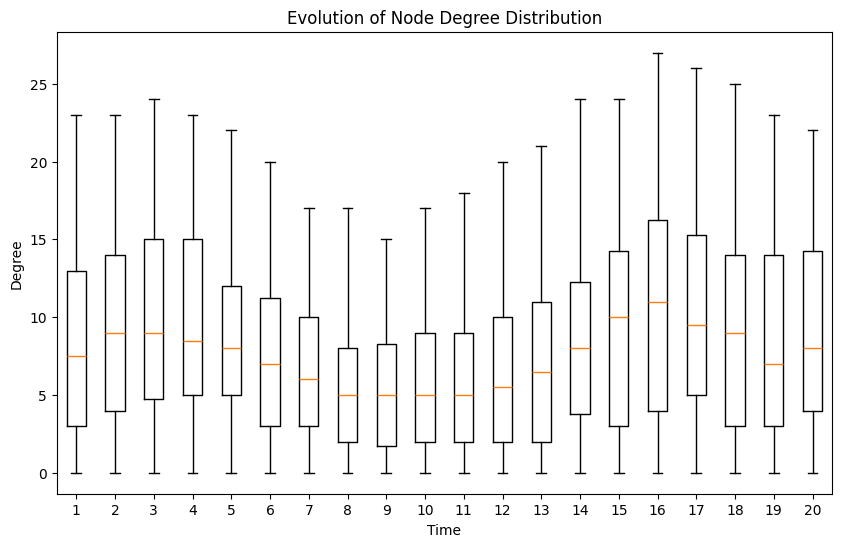

In [6]:
##pour afficher les plots, il faut décommenter les lignes commenter dans la foncion analyze_degre...
swarm30 = load_swarm_data('Traces.csv', 100, 2000, 30000) #30km
analyze_degree_distribution(swarm30, range(0, 2000, 100))

## Analyse 
Variation périodique dû aux mouvements orbitaux

L’essaim passe périodiquement de phases densément connectées à des phases plus clairsemées.
Cela suggère une dynamique orbitale ou spatiale structurée, où les satellites se rapprochent puis s’éloignent à intervalles réguliers.
Même dans les phases les plus faibles, le degré reste > 5 en moyenne → le réseau n’est jamais totalement fragmenté.


    Méthodes basées sur la densité
Avantages :
Pendant les pics de degré, ces méthodes peuvent facilement détecter des groupes denses avec des voisinages bien définis.
Une connectivité locale élevée permet de former des clusters compacts.
Limites :
Dans les phases creuses, la densité peut être trop faible pour franchir les seuils → clusters non détectés ou instables.
Ces méthodes peuvent produire des résultats très variables dans le temps si elles ne sont pas adaptées à une topologie changeante.

    Méthodes aléatoires / stochastiques
Avantages :
Ces approches tolèrent bien les fluctuations de degré.
Même avec un nombre modéré de voisins (degré > 5), une stratégie aléatoire peut explorer efficacement le réseau.
Remarque :
Leur efficacité augmente dans les pics de connectivité, car les chances de diffusion ou d'exploration fructueuse s'améliorent.
Moins sensibles aux baisses de degré tant que le graphe reste connecté

    Méthodes adaptatives / apprenantes
Avantages :
Les variations cycliques sont une opportunité : ces méthodes peuvent apprendre le rythme du réseau.
Elles peuvent choisir le bon moment pour transmettre ou clusteriser en fonction des retours précédents (ex : plus de succès quand le degré est élevé).
Risques :
Si elles ne s’adaptent pas au rythme du réseau, elles peuvent :
soit agir trop tôt (dans un creux),
soit rater une opportunité (si elles n'ont pas appris à reconnaître un pic).


Conclusion
L’évolution du degré de distribution montre un réseau cyclique mais jamais déconnecté, alternant entre moments très favorables (pics) et moments plus délicats (creux).
Méthodes sensibles à la densité : performantes mais vulnérables aux phases creuses → besoin d’un mécanisme de tolérance ou de mémoire.
Méthodes aléatoires : solides et régulières, mais pas toujours optimales.
Méthodes adaptatives : excellent compromis si elles capturent la structure cyclique — capables de maximiser les performances dans les pics sans sur-réagir aux creux.



### Distributions des noeuds et avec connections

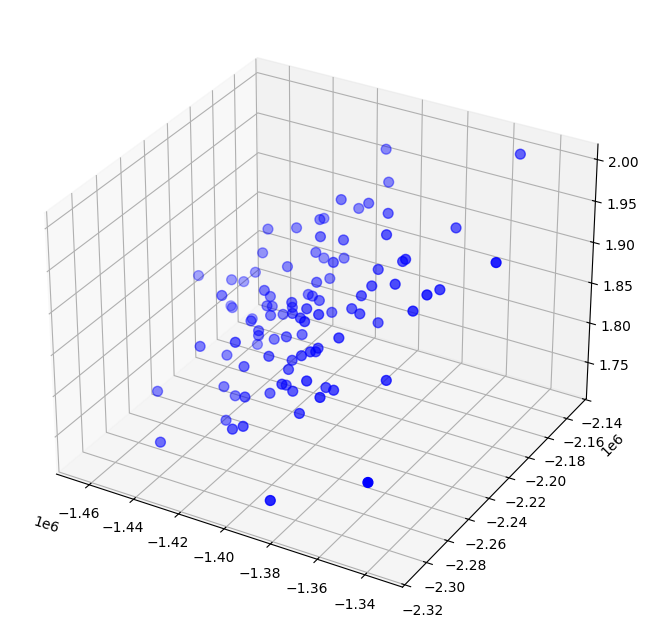

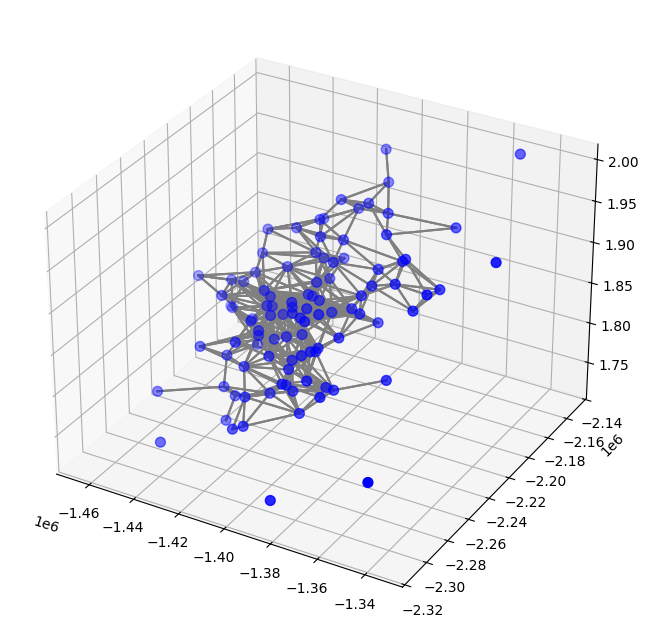

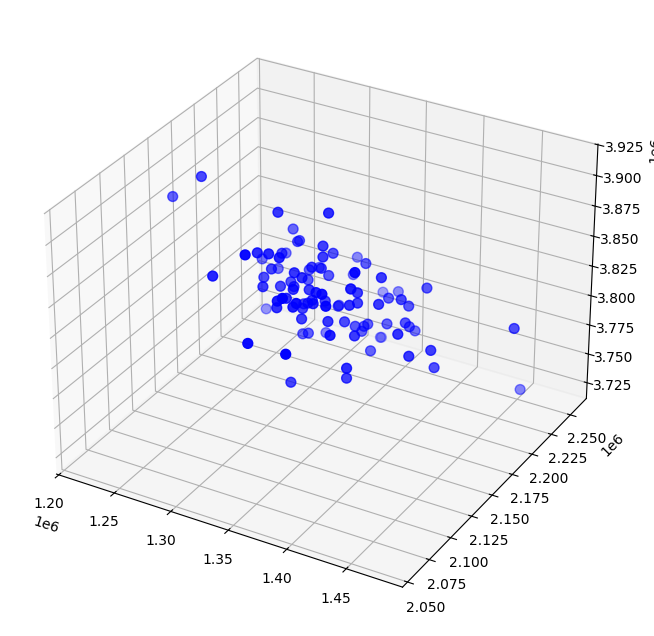

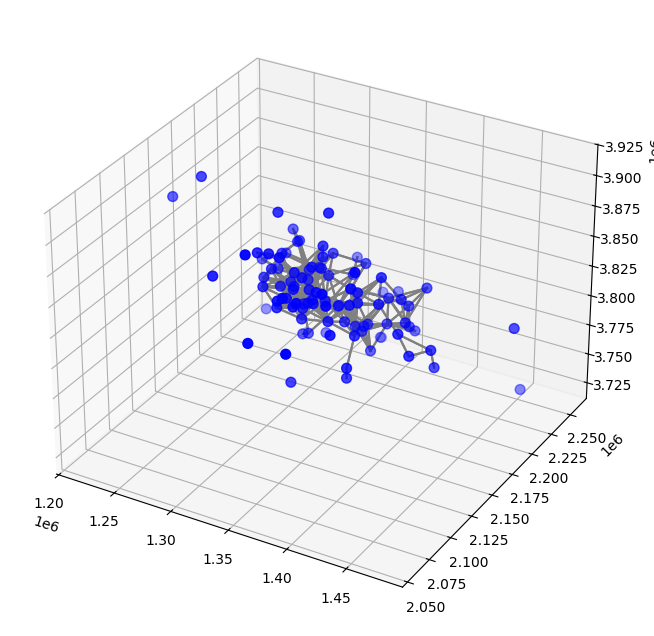

In [9]:
# Afficher l'essaim à un instant
swarm30[300].plot_nodes()
# swarm20[300].plot_edges()
swarm30[300].plot_edges()
# swarm40[300].plot_edges()
# swarm60[300].plot_edges()
swarm30[1000].plot_nodes()
# swarm20[1000].plot_edges()
swarm30[1000].plot_edges()
# swarm40[1000].plot_edges()
# swarm60[1000].plot_edges()

### Les cliques

Une clique est définie dans notre contexte comme un ensemble de nano-satellites capables de communiquer directement entre eux. On peut la lier à la notion de graphe complet.

In [9]:
def jaccard_similarity(c1, c2):
    return len(c1 & c2) / len(c1 | c2) if c1 | c2 else 0

def analyze_communities(swarms, timesteps, similarity_threshold=0.8):
    numCliques = []
    avgLen = []
    all_cliques = []
    stability = []

    for t in tqdm(timesteps, desc="Analyzing number of cliques"):
        swarm = swarms[t].swarm_to_nxgraph()
        cliques = list(nx.find_cliques(swarm))

        numCliques.append(len(cliques))
        clique_sizes = [len(c) for c in cliques]
        avgLen.append(sum(clique_sizes) / len(clique_sizes) if clique_sizes else 0)

        # Stocker les cliques comme ensembles pour faciliter la comparaison
        all_cliques.append([set(c) for c in cliques])

        # Calculer la stabilité à partir du deuxième pas de temps
        if len(all_cliques) > 1:
            prev = all_cliques[-2]
            curr = all_cliques[-1]
            matches = 0

            for c1 in prev:
                for c2 in curr:
                    if jaccard_similarity(c1, c2) >= similarity_threshold:
                        matches += 1
                        break  # On ne compte qu'une fois par clique
            stability.append(matches / len(prev) if prev else 0)

    # Statistiques de base
    print("Max cliques : ", max(numCliques))
    print("Min cliques : ", min(numCliques))
    print("AVG cliques : ", (sum(numCliques) / len(numCliques)))

    # Graphique du nombre de cliques
    plt.figure(figsize=(10, 4))
    plt.plot(numCliques)
    plt.title("Number of cliques at time t")
    plt.xlabel("Time")
    plt.ylabel("Number of cliques")
    plt.grid(True)
    plt.show()

    # Graphique de la taille moyenne
    plt.figure(figsize=(10, 4))
    plt.plot(avgLen)
    plt.title("Average size of cliques at time t")
    plt.xlabel("Time")
    plt.ylabel("Average clique size")
    plt.grid(True)
    plt.show()

    # Graphique de la stabilité
    plt.figure(figsize=(10, 4))
    plt.plot(stability)
    plt.title("Clique stability over time")
    plt.xlabel("Time")
    plt.ylabel("Fraction of stable cliques")
    plt.grid(True)
    plt.show()
    

Analyzing number of cliques: 100%|█████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 81.76it/s]

Max cliques :  160
Min cliques :  86
AVG cliques :  112.765


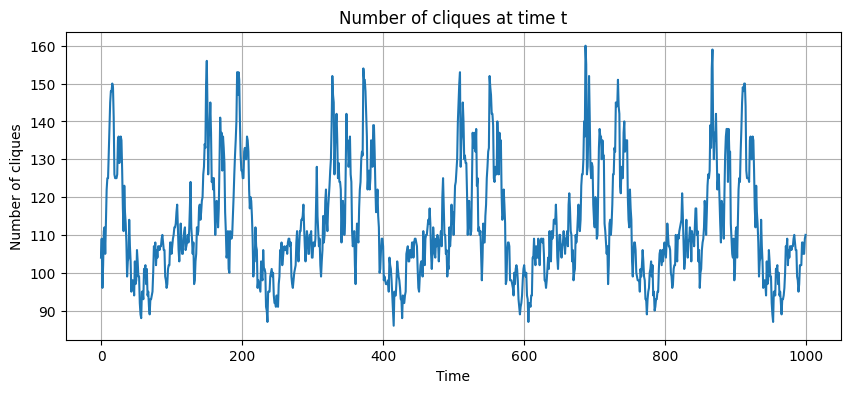

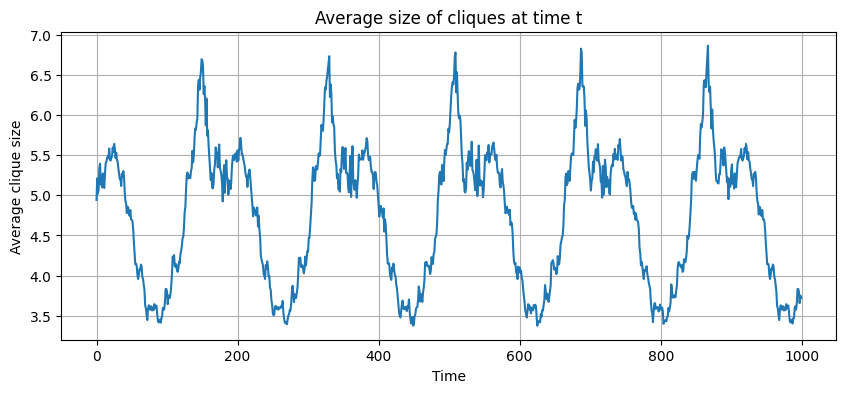

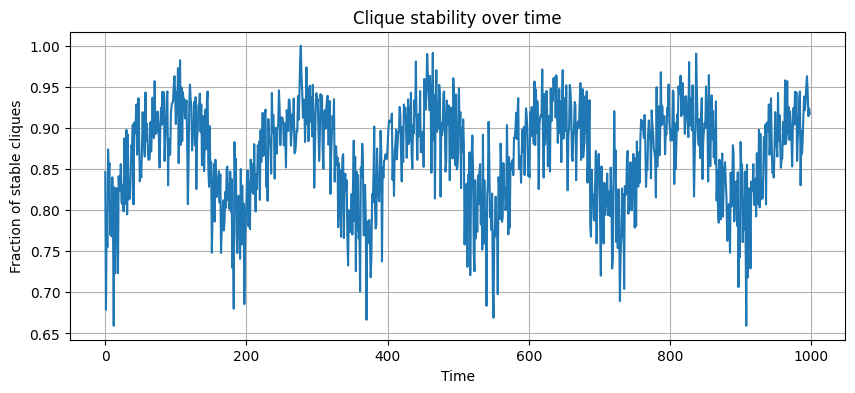

In [13]:
analyze_communities(swarm30_10000, range(0, 10000, 10))

#### Analyse des graphes

##### Nombre de cliques au cours du temps

L'évolution du nombre de cliques montre une dynamique cyclique marquée, avec des pics réguliers atteignant jusqu'à 150 cliques et des phases creuses descendant à environ 90 cliques. Cela traduit une alternance entre des phases densément connectées et des phases plus dispersées.
Lors des pics, les satellites forment de nombreux petits groupes fortement connectés. À l’inverse, les creux correspondent à des regroupements moins nombreux, probablement plus larges ou moins bien connectés. Cette variation régulière reflète une structure orbitale ou spatiale récurrente, typique d’un essaim en orbite multi-plan.


##### Taille moyenne des cliques

La taille moyenne des cliques varie également de manière cyclique, oscillant entre 3.5 et 6.5 nœuds par clique. Une observation notable est la relation inverse avec le nombre de cliques : quand le nombre de cliques augmente, leur taille moyenne diminue, et vice-versa.
Ces deux courbes combinées indiquent que, pendant les phases de haute densité, l’essaim se fragmente en petits groupes locaux. Pendant les phases de faible densité, les satellites s’organisent en cliques plus larges, mais moins nombreuses. Cela a des implications importantes pour le routage : les grandes cliques favorisent un meilleur débit au prix d’un coût énergétique plus élevé, tandis que les petites cliques privilégient l’efficacité énergétique mais risquent de ralentir la diffusion des données.


##### Stabilité des cliques

Le pourcentage de cliques stables est généralement élevé (> 80 %) mais varie au cours du temps. On observe une stabilité maximale (~95 %) autour de t = 100-130, et une diminution progressive au-delà de t = 170. La stabilité indique ici combien de cliques persistent d’un pas de temps à l’autre sans que leur composition ne change significativement.
Cette tendance suggère que la topologie du réseau évolue de manière relativement lente et prévisible sur de longues périodes. La forte stabilité des cliques signifie que leur structure ne change pas drastiquement d’un pas de temps à l’autre. Par conséquent, il n’est probablement pas nécessaire de recalculer complètement les clusters à chaque instant. Cela permettrait d’économiser du temps de calcul et de l’énergie.


#### Les méthodes de clustering adaptées

    Les méthodes qui reposent sur la densité 
Avantages :
Lors des pics de connectivité (nombre de cliques élevé), ces méthodes peuvent détecter efficacement des groupes locaux bien définis.
Limites :
Dans les creux, la densité devient insuffisante pour former des clusters robustes. Ces méthodes deviennent alors instables et peu fiables.



    Les approches aléatoires ou exploratoires
Avantages :
Leur tolérance aux variations de degré les rend adaptées aux phases instables. Elles maintiennent une performance acceptable même quand la structure devient moins claire.
Remarque :
Elles ne tirent pas pleinement parti des opportunités offertes lors des pics de densité et de stabilité.


    Méthodes adaptatives / apprenantes
Avantages :
Idéales dans un contexte cyclique, ces méthodes peuvent apprendre les moments propices à la formation de clusters (ex : autour de t = 100-150). Elles permettent de maximiser les performances dans les phases favorables tout en limitant les erreurs dans les creux.
Limites :
Si mal calibrées, elles peuvent rater les pics ou agir prématurément, notamment dans les phases instables.

    Conclusion

L’analyse des courbes met en évidence une dynamique périodique et structurée de l’essaim. Le réseau n’est jamais totalement fragmenté, mais il oscille entre des phases favorables (connectivité dense, cliques nombreuses mais petites, forte stabilité) et des phases plus délicates (cliques peu nombreuses, plus larges mais moins stables).

Les méthodes sensibles à la densité sont efficaces mais vulnérables aux phases creuses.

Les approches aléatoires sont robustes mais non optimales.

Les algorithmes adaptatifs apparaissent comme la meilleure solution pour exploiter la cyclicité du réseau.

### Le CDF des temps d'intercontact

In [ ]:
def analyze_inter_contact_times(swarms):
    node_ids = sorted(list(swarms[next(iter(swarms))].nodes), key=lambda n: n.id)
    id_to_index = {node.id: idx for idx, node in enumerate(node_ids)}
    N = len(node_ids)
    last_contact = np.full((N, N), -np.inf)
    inter_contacts = []

    sorted_times = sorted(swarms.keys(), key=int)

    for t_idx, t in enumerate(sorted_times):
        swarm = swarms[t]
        nodes = {node.id: node for node in swarm.nodes}
        for i in range(N):
            for j in range(i + 1, N):
                id_i, id_j = node_ids[i].id, node_ids[j].id
                if id_i in nodes and id_j in nodes:
                    d = nodes[id_i].compute_dist(nodes[id_j])
                    if d <= swarm.connection_range:
                        if last_contact[i, j] > -np.inf:
                            dt = t_idx - last_contact[i, j]
                            inter_contacts.append(dt)
                        last_contact[i, j] = t_idx

    # Visualisation
    sns.ecdfplot(inter_contacts)
    plt.title("CDF des temps inter-contact")
    plt.xlabel("Pas de temps")
    plt.ylabel("Proportion")
    plt.show()

    print(f"Inter-contact moyen : {np.mean(inter_contacts):.2f}")
    print(f"Inter-contact médian : {np.median(inter_contacts):.2f}")



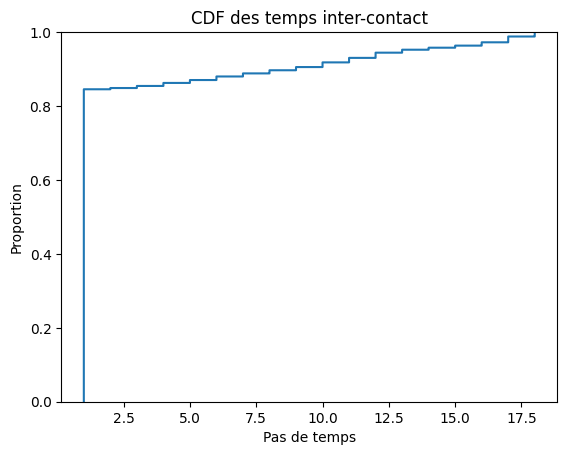

Inter-contact moyen : 2.52
Inter-contact médian : 1.00


In [7]:
analyze_inter_contact_times(swarm30)

Les contacts se reforment très rapidement (80 % en moins de 2.5 unités de temps, médiane = 1), ce qui indique :

une proximité fréquente entre les nœuds,
une structure temporairement dense dans certaines zones,
et une bonne connectivité moyenne.

    Les méthodes qui reposent sur la densité 
Avantages :
La forte fréquence des contacts signifie que des composantes cohésives se reforment régulièrement.
On peut identifier des clusters fiables dans le temps, surtout dans le cœur de l’essaim.
Limites :
Ces méthodes peuvent ignorer les paires rares ou marginales, et considérer qu’elles sont “hors cluster”.
Si elles ne tolèrent pas des délais de reconnexion élevés, elles peuvent faussement déclarer une rupture de cluster.



    Les approches aléatoires ou exploratoires
Avantages :
Parfaitement adaptées à ce contexte : elles n’ont pas besoin de contacts stables, seulement de contacts fréquents.
Elles profitent naturellement de la courte attente moyenne pour avancer rapidement dans le réseau.
Remarque :
Même si certaines paires mettent longtemps à se revoir, la haute connectivité générale permet à ces méthodes de contourner les cas rares.


    Méthodes adaptatives / apprenantes
Avantages :
Ces méthodes peuvent déduire des patterns temporels de rencontre : "avec qui ai-je le plus de chances de me reconnecter vite ?"
Elles peuvent s’auto-optimiser en favorisant les partenaires les plus récurrents et en adaptant la stratégie aux fluctuations.
Limites :
Elles nécessitent un temps d’apprentissage : au début, elles peuvent perdre du temps sur des nœuds à contacts rares.
Risque de biais si l’historique est insuffisant pour capturer toute la variabilité.

    Conclusion
Les temps inter-contact suggèrent un réseau très actif, localement très dense, avec des cas marginaux isolés.
Méthodes basées sur la densité : efficaces dans le cœur de l’essaim, mais doivent intégrer une tolérance temporelle pour éviter de "détruire" un cluster à cause d’un délai ponctuel.
Méthodes aléatoires : très bien adaptées, car la fréquence globale élevée compense le manque de structure.
Méthodes adaptatives : excellentes si elles ont le temps d’observer les dynamiques, car elles peuvent exploiter la fréquence dominante tout en évitant les exceptions.



In [4]:
def analyse_evol_diameter(swarms):
    diameters = []
    source_ids = []
    target_ids = []
    diameter_pairs = []

    for key in swarms.keys():
        swarm = swarms[key]
        source, target, diameter = swarm.diameter(swarm)
        diameters.append(diameter)
        source_ids.append(source)
        target_ids.append(target)
        diameter_pairs.append(tuple(sorted((source, target))))

    # Courbe d’évolution du diamètre
    plt.figure(figsize=(10, 5))
    plt.plot(swarms.keys(), diameters, marker='o', linestyle='-', color='blue')
    plt.title("Évolution du diamètre du swarm")
    plt.xlabel("Temps")
    plt.ylabel("Diamètre")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Histogramme des couples les plus fréquents
    # pair_counts = Counter(diameter_pairs)
    # top_pairs = pair_counts.most_common()

    # pairs_str = [f"{p[0]}-{p[1]}" for p, _ in top_pairs]
    # counts = [c for _, c in top_pairs]

    # plt.figure(figsize=(12, 6))
    # plt.bar(pairs_str, counts, color='orange')
    # plt.xticks(rotation=45, ha='right')
    # plt.title("Fréquence des couples (source, target) les plus éloignés")
    # plt.xlabel("Couples de nœuds (source-target)")
    # plt.ylabel("Nombre d'occurrences comme diamètre")
    # plt.tight_layout()
    # plt.show()


Loading swarm data: 100%|████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 152.87it/s]


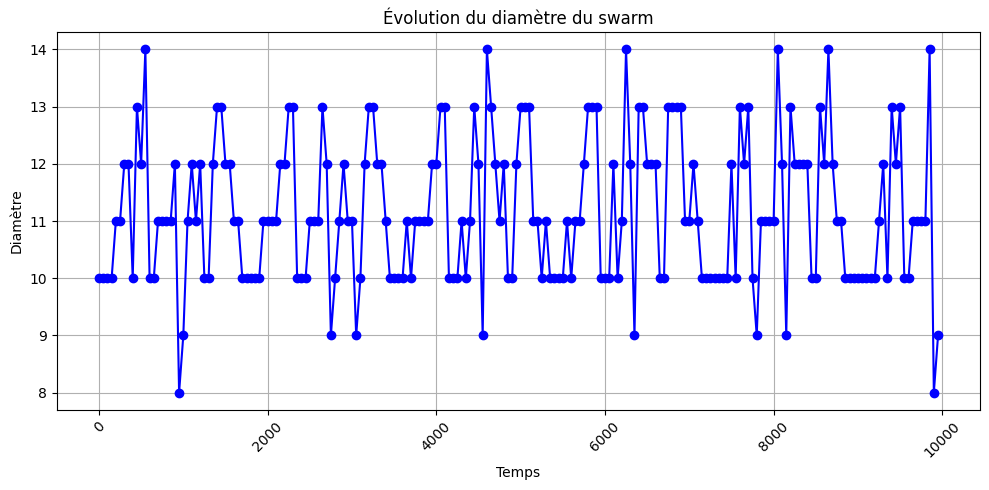

In [5]:
# swarm_diameters_20 = load_swarm_data('Traces.csv', 100, 10000, 20000, 50) #20km
swarm_diameters_30 = load_swarm_data('Traces.csv', 100, 10000, 30000, 50) #30km
# swarm_diameters_40 = load_swarm_data('Traces.csv', 100, 10000, 40000, 50) #40km
# swarm_diameters_60 = load_swarm_data('Traces.csv', 100, 10000, 60000, 50) #60km

# analyse_evol_diameter(swarm_diameters_20)
analyse_evol_diameter(swarm_diameters_30)
# analyse_evol_diameter(swarm_diameters_40)
# analyse_evol_diameter(swarm_diameters_60)

Connectivité globale maintenue:
Un diamètre de 8 à 14 pour 100 nœuds → le réseau reste connecté même quand il “s’étale”.
Cela signifie qu’il n’y a pas de grosses cassures ou d’îlots isolés.
Oscillations modérées dans le temps:
Ce comportement reflète une dynamique fluide, où l’essaim se dilate et se contracte périodiquement


    Méthodes basées sur la densité
Avantages :
Le faible diamètre garantit la connexité → des clusters formés restent potentiellement “voisins” les uns des autres, même en périphérie.
Les clusters peuvent collaborer efficacement sans trop de sauts.
Limites :
Si un cluster est trop grand, son diamètre interne augmente, ce qui pénalise l’énergie et le délai de routage.

    Méthodes aléatoires / opportunistes
Avantages :
Ces méthodes tolèrent les grands diamètres : même si le chemin est long, elles peuvent le parcourir avec des essais successifs.
Les changements de diamètre n’affectent pas leur logique : elles “rebondissent” d’un satellite à l’autre sans avoir besoin de vue globale.
Risques :
Plus le diamètre est élevé, plus ces méthodes risquent de faire des sauts inutiles ou redondants → augmentation du coût énergétique.


    Méthodes adaptatives / apprenantes
Avantages :
Ces méthodes peuvent apprendre à éviter les zones à long chemin, ou à se replier vers des zones plus centrales.
Avec une vision locale + feedback, elles optimisent les routes pour minimiser l’impact du diamètre.
Opportunité :
Les variations du diamètre peuvent servir de signal pour adapter dynamiquement la stratégie (ex. : "le graphe est tendu → je limite la portée").


    Conclusion
L’évolution du diamètre reflète un réseau bien connecté, avec une structure stable mais souple, sans isolation.
Méthodes topologiques : bien adaptées, surtout si elles intègrent une limite sur la taille interne des clusters.
Méthodes aléatoires : performantes mais plus coûteuses quand le diamètre augmente.
Méthodes adaptatives : meilleures candidates si elles peuvent exploiter le profil du diamètre pour moduler la portée, les sauts ou les partenaires.



### Densité de l'essaim au cours du temps

In [10]:
def analyse_densite(swarms):
    densites=[]
    for key in swarms.keys():
        swarm = swarms[key]
        densites.append(swarm.graph_density())


    plt.figure(figsize=(10, 5))
    plt.plot(swarms.keys(), densites, marker='o',linestyle='-', color='blue')
    plt.title("Évolution de la densité du swarm")
    plt.xlabel("Temps")
    plt.ylabel("Densité (0 à 1)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
        
    

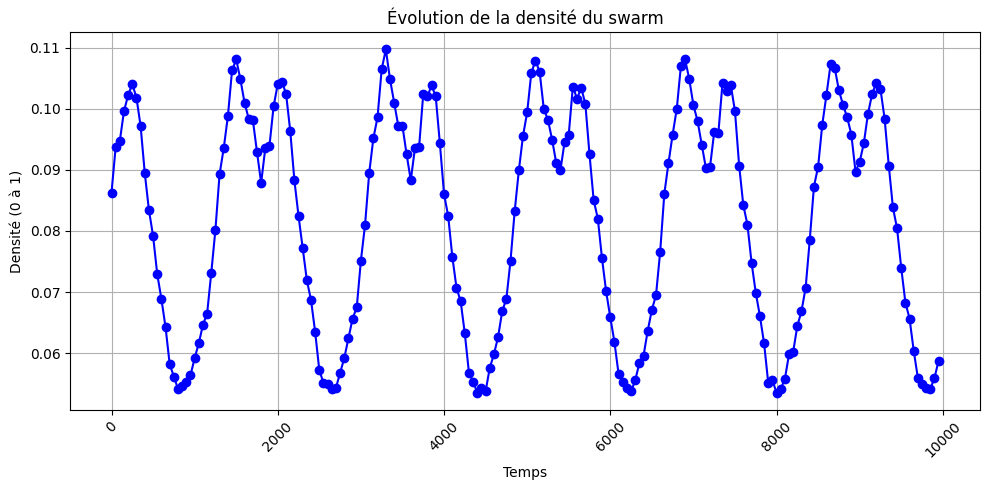

In [11]:
# analyse_densite(swarm_diameters_20)
analyse_densite(swarm_diameters_30)
# analyse_densite(swarm_diameters_40)
# analyse_densite(swarm_diameters_60)

Densité modérée, mais jamais faible
Même au plus bas, plus de 5 % des paires sont connectées → le réseau n’est jamais complètement “cassé”.
À 0.11, tu es dans une phase localement dense, très favorable à la communication directe et à la formation de clusters.

    Méthodes basées sur la densité
Avantages :
Lors des pics de densité (0.11), ces méthodes peuvent former de vrais clusters bien définis, avec suffisamment de voisins proches.
Elles peuvent tirer profit du moment cyclique où tout le monde est proche, pour faire des regroupements efficaces.
Limites :
En période creuse (densité ≈ 0.055), ces méthodes peuvent échouer à créer des clusters valides, ou créer trop de petits groupes isolés.
Le choix de seuils statiques devient risqué dans un contexte oscillant → il faut les adapter au temps.

    Méthodes aléatoires
Avantages :
Ces méthodes fonctionnent même avec peu de connexions → elles ne dépendent pas directement de la densité.
Elles peuvent avancer lentement pendant les creux, puis accélérer lors des pics, naturellement.
Opportunité :
Dans un réseau oscillant, elles bénéficient d’une redondance naturelle : si un chemin est bloqué maintenant, il peut apparaître dans 2 pas de temps → robustesse élevée.

    Méthodes adaptatives / apprenantes
Avantages :
La périodicité est un signal d’apprentissage fort → ces méthodes peuvent apprendre à anticiper les pics de densité.
Elles peuvent s’optimiser en attendant les bonnes phases pour agir, ou en adaptant leur rayon de transmission dynamiquement.
Astuce :
Elles pourraient moduler la portée ou l’énergie en fonction de la densité prédite → faible densité = portée longue, forte densité = portée courte.

    Conclusion
L'essaim présente une connectivité modérée mais stable, avec une pulsation périodique très exploitable.
Les méthodes se basant sur la densité sont efficaces dans les pics, mais doivent être adaptées ou hybridées pour gérer les creux.
Les méthodes aléatoires sont robustes face aux variations, et profitent de la densité montante pour accélérer.
Les méthodes adaptatives sont les mieux placées si elles apprennent la période → elles peuvent synchroniser leur comportement avec la densité.




### Evolution de l'ACC

In [12]:
def analyze_ACC(swarms):
    clusterings=[]
    for key in swarms.keys():
        swarm = swarms[key]
        G = swarm.swarm_to_nxgraph()
        clusterings.append(nx.average_clustering(G))

    plt.figure(figsize=(10, 5))
    plt.plot(swarms.keys(), clusterings, marker='o',linestyle='-', color='blue')
    plt.title("Évolution du coefficient de clustering moyen")
    plt.xlabel("Temps")
    plt.ylabel("coefficient de clustering moyen")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
def plot_average_clustering_distribution(swarms):
    node_clustering_sum = {}
    node_counts = {}

    for time_key in swarms.keys():
        swarm = swarms[time_key]
        G = swarm.swarm_to_nxgraph()
        clustering_per_node = nx.clustering(G)

        for node, clust_val in clustering_per_node.items():
            node_clustering_sum[node] = node_clustering_sum.get(node, 0) + clust_val
            node_counts[node] = node_counts.get(node, 0) + 1
    
    # Moyenne par noeud
    avg_clustering_per_node = {node: node_clustering_sum[node]/node_counts[node] for node in node_clustering_sum}

    values = list(avg_clustering_per_node.values())

    plt.figure(figsize=(8,5))
    plt.hist(values, bins=20, color='lightgreen', edgecolor='black')
    plt.title("Distribution moyenne du coefficient de clustering par nœud")
    plt.xlabel("Coefficient de clustering local moyen")
    plt.ylabel("Nombre de nœuds")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


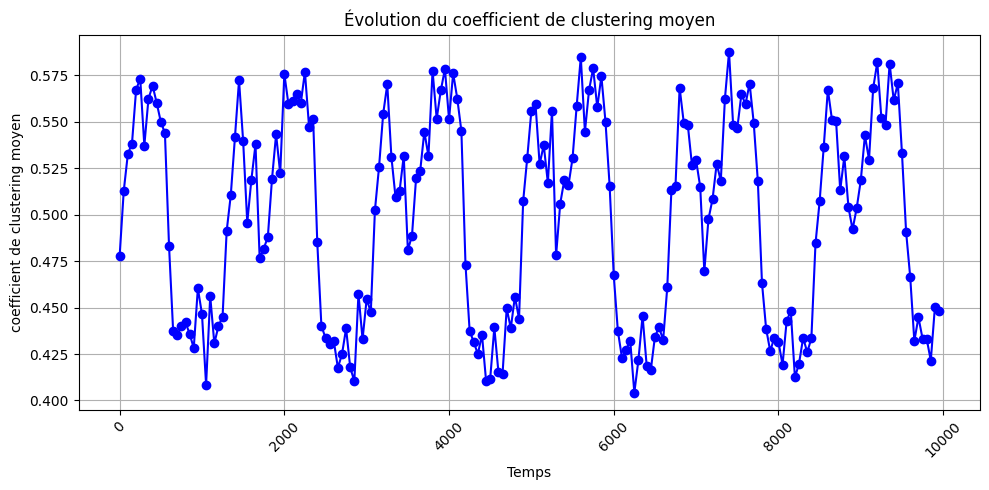

In [14]:
# analyze_ACC(swarm_diameters_20)
analyze_ACC(swarm_diameters_30)
# analyze_ACC(swarm_diameters_40)
# analyze_ACC(swarm_diameters_60)

Cohésion locale modérée à forte
40 à 60 % des paires de voisins d’un nœud sont aussi reliées entre elles. -> Cela montre que l’essaim forme des petits groupes locaux bien connectés, avec une bonne redondance dans les chemins courts

    Méthodes exploitant la densité
Avantages :
Ces méthodes s’appuient sur la présence de nombreux triangles pour détecter des clusters solides.
En phase haute (ACC ~0.6), les clusters sont stables, denses et faciles à détecter.
Limites :
En phase basse (ACC ~0.4), les clusters peuvent être plus lâches ou fragmentés.
Les méthodes avec seuils statiques doivent être ajustées pour ne pas fragmenter le réseau inutilement.

    Méthodes aléatoires
Avantages :
Une bonne cohésion locale signifie qu’il y a plusieurs chemins alternatifs proches pour relayer les données.
Cela renforce la robustesse face à la mobilité et aux pertes temporaires de liens.
Opportunité :
Ces méthodes peuvent naviguer facilement en exploitant la redondance locale, même si l’ACC baisse temporairement.

    Méthodes adaptatives / apprenantes
Avantages :
Le caractère périodique de l’ACC est une information exploitable pour apprendre quand intensifier ou réduire l’activité de clustering/routage.
Ces méthodes peuvent adapter leur comportement au “cycle” du réseau (ex : varier la taille des clusters ou la portée des transmissions).
Astuce :
Utiliser le suivi du coefficient de clustering pour moduler dynamiquement les paramètres de regroupement.


    Méthodes adaptatives / apprenantes
Pas favorisé, ni défavorisé : 
Ce n’est ni un environnement complètement stable (où l’adaptativité serait peu utile, car tout est constant),
Ni un environnement très chaotique (où l’adaptativité serait indispensable pour s’ajuster rapidement).

    Conclusion
L'essaim présente une cohésion locale dynamique modérée à élevée, oscillant régulièrement avec la topologie globale.

Les algorithmes exploitant la densité seront particulièrement efficaces dans les phases hautes.
Les méthodes opportunistes sont naturellement robustes aux fluctuations du clustering.
Les méthodes adaptatives tirent le meilleur parti de cette périodicité en adaptant leur stratégie temporellement.



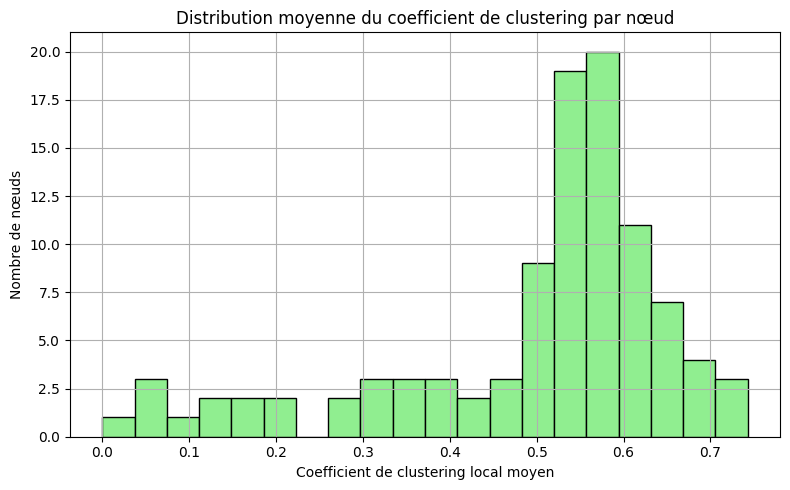

In [15]:
plot_average_clustering_distribution(swarm_diameters_30)

### La variation de la taille de la composante principale dans le temps

Forte concentration autour d’un intervalle étroit (0.55 à 0.6)
La majorité des nœuds (près de 50 sur 100) ont un coefficient de clustering situé dans une fourchette réduite, proche de 0.58.
Cela indique que la plupart des satellites ont un voisinage local assez homogène en termes de connectivité, avec environ 55-60 % des voisins interconnectés.

Pic unique dominant → faible hétérogénéité locale
Peu de nœuds sortent de cette zone de clustering moyen, ce qui montre un réseau plutôt uniforme dans sa structure locale

Très peu de nœuds avec clustering faible ou très élevé
Le fait que les autres valeurs ont en moyenne 2.5 nœuds ou moins signifie que peu d’acteurs ont une structure locale atypique (ni très faible ni très forte cohésion).

    Méthodes basées sur la densité
Avantage :
Ces méthodes peuvent bénéficier de cette homogénéité locale, car la majorité des nœuds partage un environnement similaire, ce qui rend la détection de clusters plus stable et fiable.
Limite :
Risque de “masquer” des sous-structures fines si tous les nœuds sont traités de la même façon, nécessité d’intégrer une granularité adaptative.

    Méthodes opportunistes / aléatoires
Avantage :
Elles profitent de la régularité locale pour propager efficacement les messages sans “trous” de connectivité marqués.
Opportunité :
Peu d’irrégularités signifie moins d’interruptions dans les chemins opportunistes.

    Méthodes adaptatives / apprenantes
Avantage :
Elles peuvent utiliser cette distribution stable pour calibrer des paramètres globaux et éviter des ajustements trop locaux inutiles.
Cela simplifie l’apprentissage en réduisant la variance locale à modéliser.

    Conclusion
La distribution du coefficient de clustering montre un essaim relativement homogène dans sa cohésion locale, avec une majorité de satellites ayant un environnement à 55-60 % de voisins interconnectés.
Cela suggère un réseau où la topologie locale est stable et uniforme, un terrain idéal pour des méthodes de clustering basées sur la densité ou la cohésion, tout en étant très favorable aux approches opportunistes et adaptatives.




In [6]:
def compute_and_plot_largest_component(swarms):
    
    largest_sizes = {}

    for t, swarm in swarms.items():
        components = swarm.connected_components()
        max_size = max((len(c) for c in components), default=0)
        largest_sizes[t] = max_size

    # Tri pour l'affichage
    timestamps = sorted(largest_sizes.keys())
    sizes = [largest_sizes[t] for t in timestamps]

    # Tracé
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps, sizes, marker='s', color='green', linestyle='-')
    plt.xlabel("Timestamp")
    plt.ylabel("Taille de la composante principale")
    plt.title("Évolution de la composante connexe principale dans le swarm")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def compute_and_plot_num_components(swarms):

    num_components = {}

    for t, swarm in swarms.items():
        components = swarm.connected_components()
        num_components[t] = len(components)

    # Tri pour affichage
    timestamps = sorted(num_components.keys())
    counts = [num_components[t] for t in timestamps]

    # Tracé
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps, counts, marker='o', color='orange', linestyle='-')
    plt.xlabel("Timestamp")
    plt.ylabel("Nombre de composantes connexes")
    plt.title("Évolution du nombre de composantes connexes dans le swarm")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return num_components


def plot_component_size_distribution(swarm, timestamp=None):

    components = swarm.connected_components()
    sizes = [len(c) for c in components]

    plt.figure(figsize=(10, 6))
    plt.hist(sizes, bins=range(1, max(sizes) + 2), color='skyblue', edgecolor='black', align='left')
    plt.xlabel("Taille des composantes connexes")
    plt.ylabel("Nombre de composantes")
    title = "Distribution des tailles des composantes connexes"
    if timestamp is not None:
        title += f" au temps {timestamp}"
    plt.title(title)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


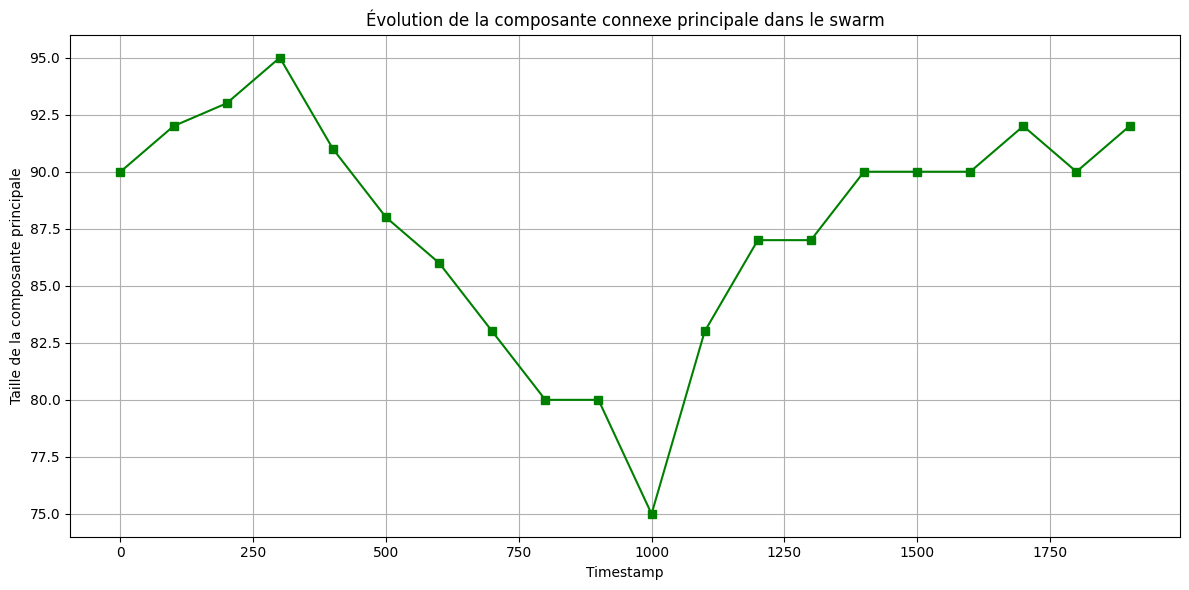

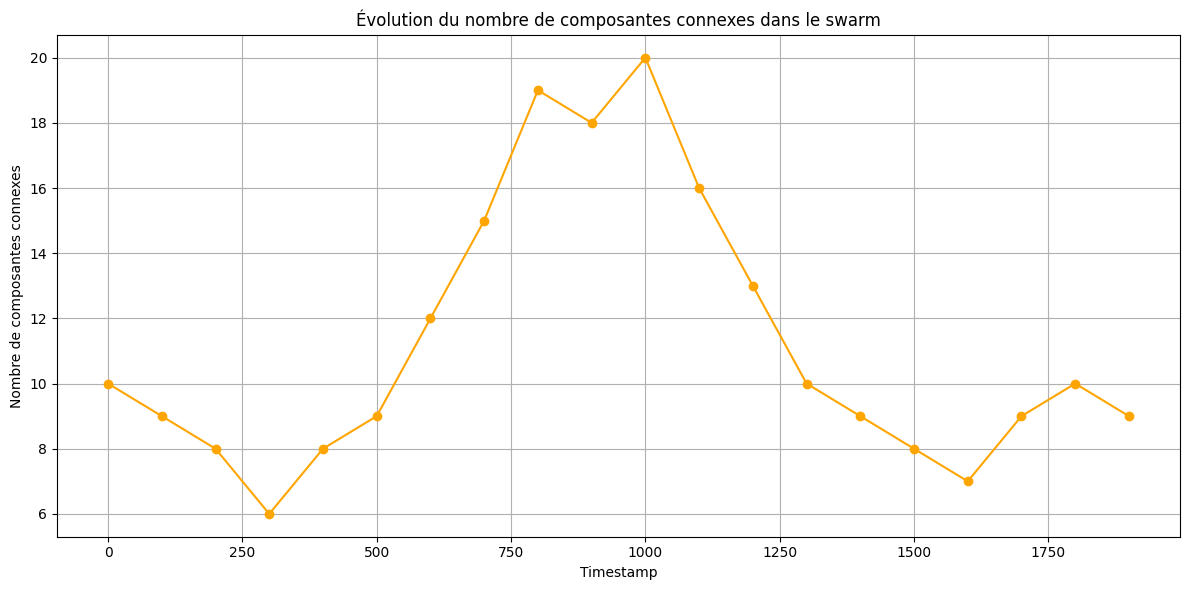

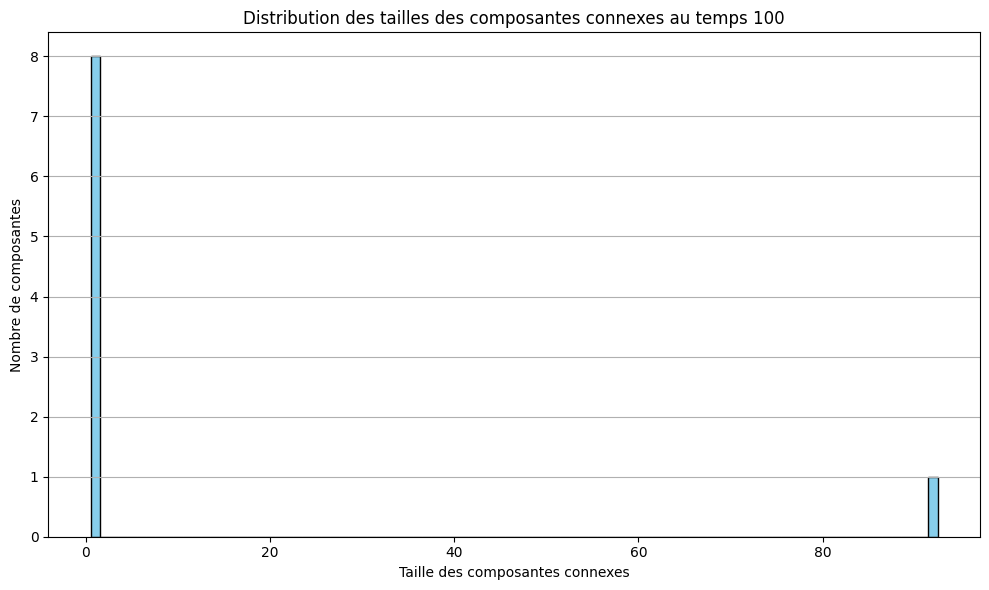

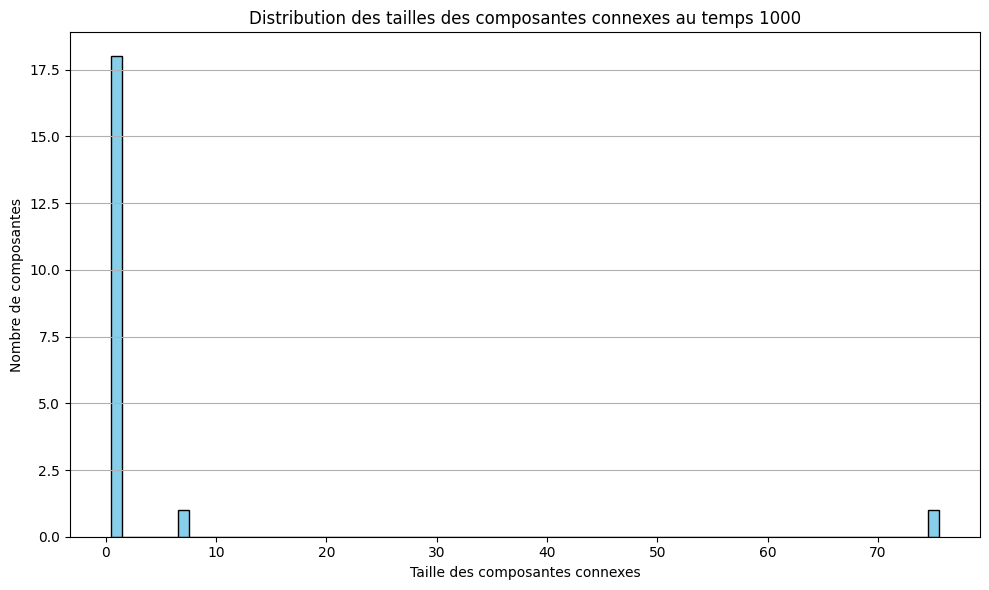

In [10]:
compute_and_plot_largest_component(swarm30)
compute_and_plot_num_components(swarm30)
plot_component_size_distribution(swarm30[100], timestamp='100')
plot_component_size_distribution(swarm30[1000], timestamp='1000')

# compute_and_plot_largest_component(swarm40)
# compute_and_plot_largest_component(swarm60)

La composante principale regroupe à peu près 90% des nœuds, ce qui indique que la vaste majorité du swarm est connectée de manière robuste. Les autres noeuds sont compris dans des composantes de très petite tailles.
Par exemple, à l'instant 100, il y a la composante principale composé de 82 noeuds, et 8 autres composante de taille 1. A l'instant 1000, la taille de la composante principale diminue alors que le nombre de composantes augmente: l'essaim se retrouve avec une composante principale de taille 75, 18 composantes de taille 1 et une composante de taille 7.

    Méthodes basées sur la densité
Avantage :
La grande composante fournit un noyau très dense, favorable à une détection robuste de cluster principal.
Limite :
Les nœuds isolés ou récemment expulsés du réseau seront exclus des clusters, ce qui risque de fausser la détection ou de négliger des zones en transition.

    Méthodes aléatoires
Avantage :
Le réseau fortement connecté permet une diffusion efficace et rapide, sans goulot d’étranglement.
Limite :
Les nœuds isolés ne seront jamais atteints sans mécanisme de réintégration ou de bufferisation des messages.

    Méthodes adaptatives / apprenantes
Avantage :
La stabilité topologique du noyau facilite l’apprentissage de paramètres globaux cohérents et fiables.
Limite :
Risque de biais structurel si les nœuds isolés sont sous-représentés ou ignorés pendant l’entraînement → modèle peu généralisable en cas de déconnexion accrue.

    Conclusion
La distribution révèle un swarm très centralisé, avec une connectivité globale dominante et quelques isolats marginaux.
Un tel réseau offre un terrain favorable :
Aux méthodes fondées sur la densité (fort cœur compact)
Aux approches opportunistes (propagation fluide)
Aux systèmes apprenants (structure stable)
… mais nécessite de traiter explicitement les nœuds isolés, sous peine d’ignorer les dynamiques périphériques du système.



## Résumé de l'analyse de l'essaim : 

Le réseau présente une connectivité robuste et dynamique, avec un degré moyen toujours supérieur à 5, assurant une liaison constante entre les nœuds. Les temps d’intercontact très courts (médiane de 1, 80 % sous 2.5 unités de temps) permettent une reformation rapide des liens, favorisant la diffusion rapide des informations. Le diamètre reste modéré (entre 8 et 14), ce qui limite le nombre de sauts nécessaires pour atteindre un nœud. La densité globale oscille modérément (de 0.055 à 0.11) sans jamais s’effondrer, ce qui garantit une structure connectée même en période creuse. Le clustering local (ACC) varie entre 0.4 et 0.6, traduisant une bonne cohésion locale avec des triangles fréquents. De plus, la distribution du clustering est homogène, la majorité des nœuds partageant un voisinage similaire (autour de 0.58), ce qui réduit la variance topologique locale. Enfin, la composante principale regroupe en permanence environ 90 % des nœuds, témoignant d’un noyau central très stable, tandis que les autres nœuds forment de petits isolats temporaires.

| Stratégies                    | Avantages                                                                                   | Limites / Risques                                                                                     |
|-------------------------------|---------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------|
| Méthodes basées sur la densité | - Bonne détection de clusters dans les phases de forte connectivité<br>- Exploitent les pics de densité et de clustering<br>- Favorisent des regroupements stables | - Sensibles aux phases creuses (faible densité, fragmentation)<br>- Seuils statiques risqués dans un réseau oscillant<br>- Excluent les nœuds isolés ou marginaux |
| Méthodes aléatoires / opportunistes | - Tolèrent bien les fluctuations de densité et de degré<br>- Fonctionnent même avec des connexions intermittentes<br>- Exploitent la redondance locale pour robustesse | - Peu optimales en termes d’efficacité énergétique quand le diamètre est élevé<br>- Ne couvrent pas les nœuds isolés sans mécanismes supplémentaires |
| Méthodes adaptatives / apprenantes | - Peuvent apprendre les rythmes cycliques du réseau<br>- Optimisent la stratégie en fonction du contexte (pic ou creux)<br>- Modulent la portée et l’énergie selon la densité prédite | - Nécessitent un temps d’apprentissage<br>- Risque de biais si historique insuffisant<br>- Peuvent rater des opportunités si mal calibrées |


# Analyse Comparative des Algorithmes de Clustering pour Essaims de Nano-Satellites

Dans un premier temps, nous définissons les critères qui serviront à évaluer nos algorithmes de clustering.

### Métriques d'Évaluation
- **Débit (Throughput)** : Performance de communication
- **Efficacité énergétique** : Consommation d'énergie optimisée
- **Connectivité** : Qualité des connexions inter-nœuds
- **Équilibrage de charge** : Distribution équitable des nœuds
- **Gain de communication** : Optimisation des liens de communication

### Algorithmes Analysés
- **FFD (Forest Fire)** : Algorithme de propagation par feu de forêt
- **MDRW (Multi-Dimensional Random Walk)** : Marche aléatoire multi-dimensionnelle  
- **RND (Random)** : Clustering aléatoire
- **DBSCAN** : Algorithme de clustering basé sur la densité


Avec ces critères, l'objectif est de :

1. **Tester les algorithmes de clustering** en fonction du nombre de clusters
2. **Analyser DBSCAN** et déterminer le nombre de clusters qu'il utilise
3. **Créer des visualisations** pour comparer les algorithmes
4. **Trouver le nombre optimal de clusters** pour chaque algorithme
5. **Déterminer la configuration optimale** qui offre le meilleur ajustement global




##  Définition des critères d'évaluation des méthodes de clustering



### a. Équilibrage de Charge

#####  Répartition homogène des satellites dans les clusters

. éviter la saturation des clusters(risque de congestion, collisions)

. Répartiotion équitable des tâches de traitement ou de relai


In [6]:
def evaluate_load_balancing(clusters):
    """
    Évalue l'équilibrage de charge entre les clusters
    Plus l'écart-type est faible, meilleur est l'équilibrage
    """
    cluster_sizes = [len(cluster.nodes) for cluster in clusters.values()]
    return np.std(cluster_sizes)

### b. Consommation d'Énergie

In [7]:
def calculate_energy_consumption(cluster):
    """
    Calcule la consommation d'énergie en prenant en compte :
    - La distance de communication
    - La surcharge des nœuds (congestion)
    
    Modèle :
    - L'énergie augmente avec la distance
    - L'énergie augmente avec le nombre de voisins (congestion)
    """
    total_energy = 0

    for node in cluster.nodes:
        congestion_factor = 1 + 0.05 * node.degree()  # 5% d’énergie en plus par voisin

        for neighbor in node.neighbors:
            d = node.compute_dist(neighbor)
            if d > 40000:  # lien longue portée
                energy = (d * 3) * congestion_factor
            else:
                energy = d * congestion_factor

            total_energy += energy

    return total_energy

### c. Débit (étude du nombre moyen de connexions intra-cluster)

. Plus les satellites sont proches, meilleur est le débit

. Plus ils sont éloignés, plus le signal est faible (débit réduit dû au bruit thermiques des autres composants électroniques, rayonnement solaire/cosmique)

. Interférences avec d'autres satellites

In [8]:
def estimate_throughput(node, neighbor):
    """
    Estime le débit (en Mbps) entre deux satellites selon leur distance.

    Portée           Débit
    ------------------------
    ≤ 10 km          100 Mbps
    ≤ 20 km          50 Mbps
    ≤ 29 km          10 Mbps
    > 29 km          0 Mbps (pas de liaison)
    """
    d = node.compute_dist(neighbor)
    if d <= 10000:
        return 100
    elif d <= 20000:
        return 50
    elif d <= 29000:
        return 10
    else:
        return 0



def total_cluster_throughput(cluster):
    total = 0
    visited = set()
    for node in cluster.nodes:
        for neighbor in node.neighbors:
            pair = tuple(sorted((node.id, neighbor.id)))
            if pair in visited:
                continue
            visited.add(pair)
            total += estimate_throughput(node, neighbor)
    return total


### d. Connectivité/ Résilience

Mesure à quel point les noeuds sont reliés entre eux dans un cluster

In [9]:
def average_connectivity(cluster):
    return np.mean([node.degree() for node in cluster.nodes])

### e. Gain avec clustering

In [10]:
def count_intra_cluster_links(clusters):
    total_links = 0
    for cluster in clusters.values():
        visited = set()
        for node in cluster.nodes:
            for neighbor in node.neighbors:
                pair = tuple(sorted((node.id, neighbor.id)))
                if pair not in visited:
                    visited.add(pair)
        total_links += len(visited)
    return total_links

def compute_communication_gain(clusters):
    full_links = (100 * (100 - 1)) // 2
    cluster_links = count_intra_cluster_links(clusters)
    
    gain = 1 - (cluster_links / full_links)
    return gain  # entre 0 et 1 (ou 0% à 100%)

In [11]:
def load_swarm_data(path='Traces.csv', num_nodes=100, duration=2000):
    """
    Charge les données de l'essaim à partir d'un fichier CSV
    
    Paramètres:
    - path: chemin vers le fichier CSV contenant les traces
    - num_nodes: nombre de nœuds (satellites) dans l'essaim
    - duration: nombre de pas de temps à charger
    
    Retourne:
    - Liste des objets Swarm pour chaque pas de temps
    """
    df = pd.read_csv(path, header=None)
    swarms = []

    for t in tqdm(range(duration), desc="Chargement des données de l'essaim"):
        # Création d'un nouvel essaim avec une portée de connexion de 30km
        swarm = Swarm(connection_range=30000, nodes=[])  # 30km comme dans le papier de référence

        # Création des nœuds avec des IDs entiers simples
        nodes = [Node(id=i) for i in range(num_nodes)]

        for i in range(num_nodes):
            # Positionnement des nœuds à chaque pas de temps
            # Chaque nœud a des coordonnées x, y, z stockées dans le CSV
            x_idx = 3*i
            y_idx = 3*i + 1
            z_idx = 3*i + 2

            # Extraction des coordonnées depuis le DataFrame
            x = df.iloc[x_idx, t] if x_idx < len(df) else 0
            y = df.iloc[y_idx, t] if y_idx < len(df) else 0
            z = df.iloc[z_idx, t] if z_idx < len(df) else 0

            # Attribution des positions aux nœuds
            nodes[i].x = float(x)
            nodes[i].y = float(y)
            nodes[i].z = float(z)

        # Ajout de tous les nœuds à l'essaim
        for node in nodes:
            swarm.add_node(node)

        swarms.append(swarm) 
    return swarms

swarms = load_swarm_data('Traces.csv')
def analyze_degree_distribution2(swarms, timesteps):
    degrees = []
    for t in tqdm(timesteps, desc="Analyzing degree distribution"):
        swarm = swarms[t]
        swarm.reset_connection()
        for node in swarm.nodes:
            for other in swarm.nodes:
                if node != other:
                    node.is_neighbor(other, swarm.connection_range)
        degrees.append(swarm.degree())
    
    # Visualisation comme dans la Figure 1 du papier
    #plt.figure(figsize=(10,6))
    #plt.boxplot(degrees)
    #plt.title("Evolution of Node Degree Distribution")
    #plt.xlabel("Time")
    #plt.ylabel("Degree")
    #plt.show()
analyze_degree_distribution2(swarms, range (2000))

Analyzing degree distribution: 100%|████████| 2000/2000 [00:26<00:00, 74.15it/s]


## Etude de cas:  Evaluation de l'algorithme FFD

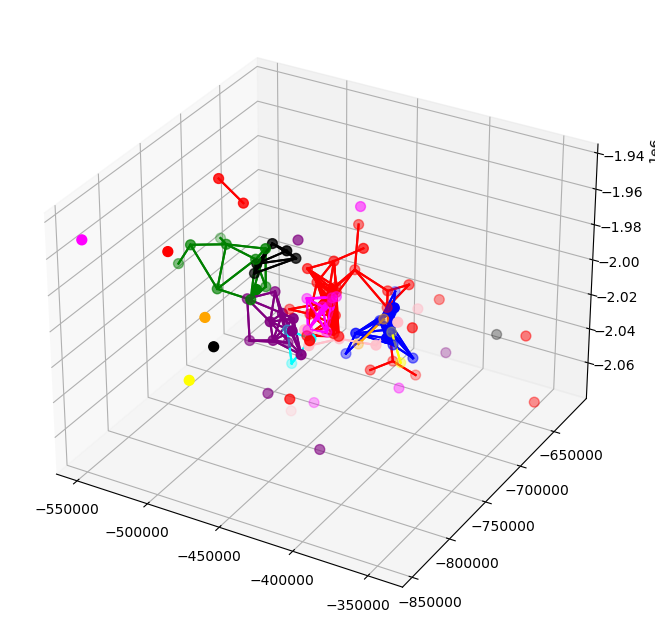

In [13]:
fig = plt.figure(figsize=(8,8))

ffd_result = swarms[0].FFD()
colors = ['red', 'blue', 'green', 'orange', 'purple', 
          'cyan', 'magenta', 'yellow', 'black', 'pink']
ax = plt.axes(projection='3d')
for i,result in enumerate(ffd_result.values()):
    x_data = [node.x for node in result.nodes]
    y_data = [node.y for node in result.nodes]
    z_data = [node.z for node in result.nodes]
    ax.scatter(x_data, y_data, z_data, c=colors[i], s=50)
    for node in result.nodes:
            for n in node.neighbors:
                if n in result.nodes:
                    ax.plot([node.x, n.x], [node.y, n.y], [node.z, n.z], c=colors[i])
                    

## Evaluation de l'algorithme FFD

In [16]:
results = []
previous_clusters = None
timesteps = range(0, 2000,100)  # exemple : 20 timestamps

for t in tqdm(timesteps, desc="Evaluating FFD"):
    swarm = swarms[t]
    swarm.reset_connection()
    swarm.neighbor_matrix()

    clusters = swarm.FFD()

    res = {
        "time": t,
        "load_balance": evaluate_load_balancing(clusters),
        "energy": np.mean(np.array([calculate_energy_consumption(c) for c in clusters.values()])),
        "throughput": np.mean(np.array([total_cluster_throughput(cluster) for cluster in clusters.values()])),
        "connectivity": np.mean([average_connectivity(c) for c in clusters.values()]),
        "gain": compute_communication_gain(clusters)
    }

    results.append(res)
    previous_clusters = clusters

    
df_results = pd.DataFrame(results)

Evaluating FFD: 100%|███████████████████████████| 20/20 [00:00<00:00, 55.41it/s]


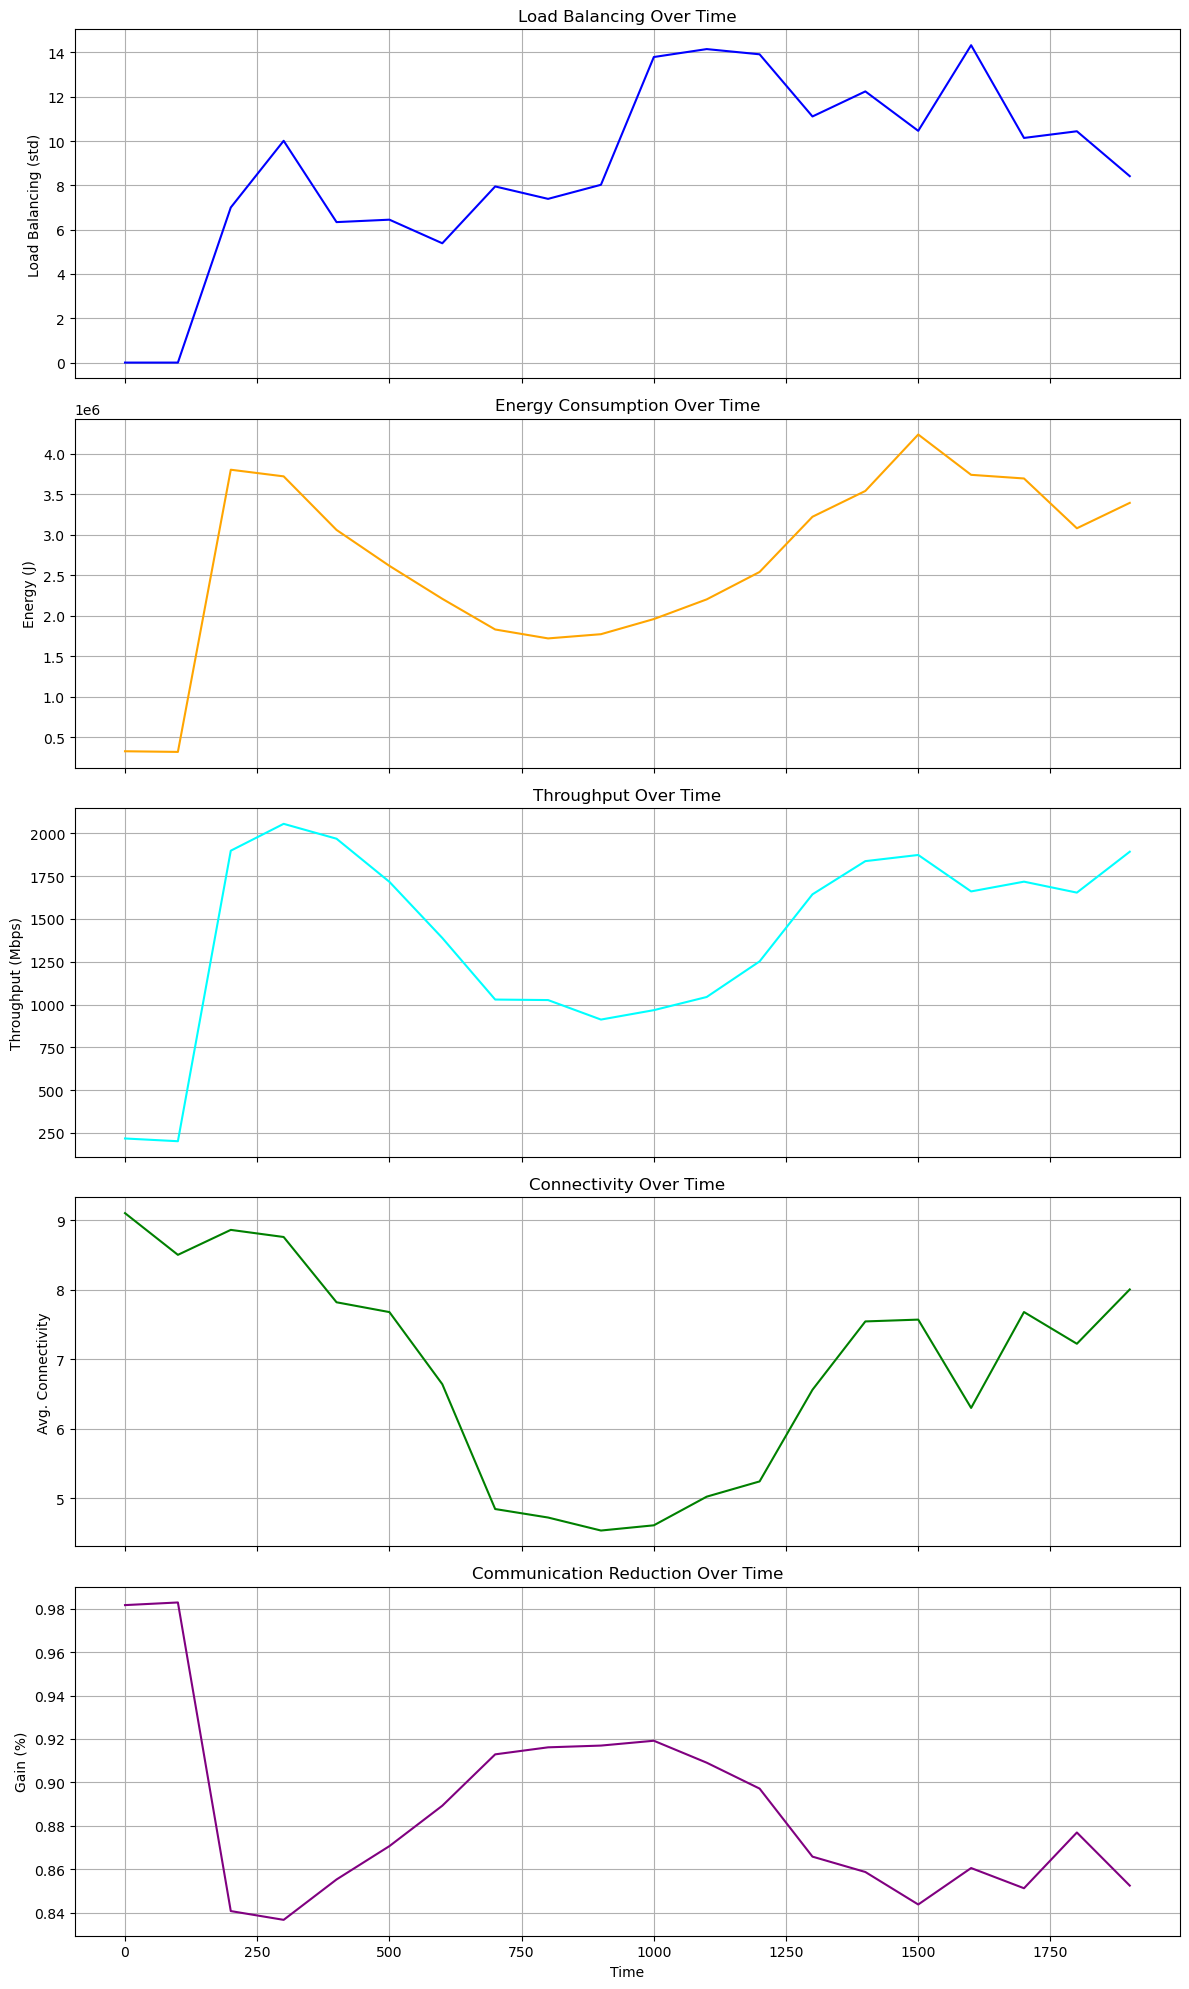

In [20]:
fig, axs = plt.subplots(5, 1, figsize=(12, 20), sharex=True)

# 1. Load Balancing (écart-type)
axs[0].plot(df_results['time'].values, df_results['load_balance'].values, color='blue')
axs[0].set_ylabel("Load Balancing (std)")
axs[0].set_title("Load Balancing Over Time")
axs[0].grid(True)

# 2. Energy Consumption
axs[1].plot(df_results['time'].values, df_results['energy'].values, color='orange')
axs[1].set_ylabel("Energy (J)")
axs[1].set_title("Energy Consumption Over Time")
axs[1].grid(True)

# 3. Throughput
axs[2].plot(df_results['time'].values, df_results['throughput'].values, color='cyan')
axs[2].set_ylabel("Throughput (Mbps)")
axs[2].set_title("Throughput Over Time")
axs[2].grid(True)

# 4. Average Connectivity
axs[3].plot(df_results['time'].values, df_results['connectivity'].values, color='green')
axs[3].set_ylabel("Avg. Connectivity")
axs[3].set_title("Connectivity Over Time")
axs[3].grid(True)

# 5. Communication Gain
axs[4].plot(df_results['time'].values, df_results['gain'].values, color='purple')
axs[4].set_ylabel("Gain (%)")
axs[4].set_title("Communication Reduction Over Time")
axs[4].set_xlabel("Time")
axs[4].grid(True)

plt.tight_layout()
plt.show()


## PROPOSITION D'UN ALGORITHME (DBSCAN)

In [12]:
from sklearn.cluster import DBSCAN

def DBSCAN_clustering(swarm, eps=30000, min_samples=10):
    """
    Clustering spatial des satellites basé sur DBSCAN.

    Args:
        swarm (Swarm): objet Swarm avec tous les satellites.
        eps (float): distance maximale entre deux points pour être dans le même cluster (ex: 20km).
        min_samples (int): nombre minimal de voisins pour être noyau.

    Returns:
        dict(int: Swarm): clusters regroupés par identifiants.
    """
    positions = np.array([[node.x, node.y, node.z] for node in swarm.nodes])
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(positions)
    
    labels = db.labels_  # -1 pour les "outliers"
    clusters = {}

    for node, label in zip(swarm.nodes, labels):
        if label == -1:
            continue  # ignorer les points considérés comme "bruit"
        node.set_group(label)
        if label not in clusters:
            clusters[label] = Swarm(connection_range=swarm.connection_range, nodes=[node])
        else:
            clusters[label].add_node(node)
    #print(len(list(clusters.values())))
    return clusters

In [13]:
def compare_clustering_algorithms(swarm, previous_clusters=None):
    algorithms = {
        'FFD': swarm.FFD,
        'MDRW': swarm.MDRW,
        'RND': swarm.RND
    }
    
    results = {}

    for name, algorithm in algorithms.items():
        clusters = algorithm()

        result = {
            "load_balance": evaluate_load_balancing(clusters),
            "energy": np.mean([calculate_energy_consumption(c) for c in clusters.values()]),
            "throughput": np.mean([total_cluster_throughput(c) for c in clusters.values()]),
            "connectivity": np.mean([average_connectivity(c) for c in clusters.values()]),
            "gain": compute_communication_gain(clusters)
        }

        if previous_clusters:
            result["stability"] = evaluate_stability(clusters, previous_clusters)
        else:
            result["stability"] = 0

        results[name] = result

    return results


In [34]:
def evaluate_algorithm(swarms, algorithm_name):
    results = []
    previous_clusters = None
    timesteps = range(0, 2000,50)

    for t in tqdm(timesteps, desc=f"Evaluating {algorithm_name}"):
        swarm = swarms[t]
        swarm.reset_connection()
        swarm.neighbor_matrix()
        swarm.reset_groups()

        # Sélection de l'algorithme
        if algorithm_name == 'FFD':
            clusters = swarm.FFD()
        elif algorithm_name == 'MDRW':
            clusters = swarm.MDRW()
        elif algorithm_name == 'RND':
            clusters = swarm.RND()
        elif algorithm_name == 'DBSCAN':
            clusters = DBSCAN_clustering(swarm, eps=30000)
        else:
            raise ValueError(f"Unknown algorithm: {algorithm_name}")

        # Résultats du timestamp t
        res = {
            "time": t,
            "load_balance": evaluate_load_balancing(clusters),
            "energy": np.mean([calculate_energy_consumption(c) for c in clusters.values()]),
            "throughput": np.mean([total_cluster_throughput(c) for c in clusters.values()]),
            "connectivity": np.mean([average_connectivity(c) for c in clusters.values()]),
            "gain": compute_communication_gain(clusters),
        }

        results.append(res)
        previous_clusters = clusters

    df_results = pd.DataFrame(results)
    return df_results.mean(numeric_only=True)


# Etude compartive des différents algorihtmes

In [35]:
ffd_mean = evaluate_algorithm(swarms, 'FFD')
mdrw_mean = evaluate_algorithm(swarms, 'MDRW')
rnd_mean  = evaluate_algorithm(swarms, 'RND')
dbscan_mean = evaluate_algorithm(swarms, 'DBSCAN')

comparison_df = pd.DataFrame({
    "FFD": ffd_mean,
    "MDRW": mdrw_mean,
    "RND": rnd_mean,
    "DBSCAN": dbscan_mean
})

#comparison_df["Complexité"] = ["O(n + e)", "O(k·n)", "O(n)", "O(n²)"]


# Afficher le tableau
print(comparison_df.round(2).T)  # .T pour transposer : algos en lignes


Evaluating DBSCAN: 100%|████████████████████████| 40/40 [00:00<00:00, 61.24it/s]

         time  load_balance       energy  throughput  connectivity  gain
FFD     975.0          9.65   2960309.24     1574.78          6.77  0.87
MDRW    975.0          0.00   2960309.24     1841.22          8.28  0.86
RND     975.0          1.95   2960309.24     2030.15          8.21  0.84
DBSCAN  975.0          3.48  26366695.44     9527.25         10.52  0.92


# Normasiation et pondération des critères afin de définir le meilleur algorithmes

In [36]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Supposons que df = comparison_df.T (algos en index, critères en colonnes)
df = comparison_df.T

scaler = MinMaxScaler()

# Critères à MINIMISER → on inverse
for col in ['energy', 'stability', 'load_balance']:
    if col in df.columns:
        df[col + '_norm'] = 1 - scaler.fit_transform(df[[col]])
    else:
        df[col + '_norm'] = 0

# Critères à MAXIMISER → normalisation simple
for col in ['throughput', 'gain', 'connectivity']:
    if col in df.columns:
        df[col + '_norm'] = scaler.fit_transform(df[[col]])
    else:
        df[col + '_norm'] = 0


df['score'] = (
    0.30 * df['throughput_norm'] +
    0.30 * df['energy_norm'] +
    0.15 * df['gain_norm'] +
    0.15 * df['connectivity_norm'] +
    0.10 * df['load_balance_norm']
)


In [37]:
ranking = df[['score']].sort_values(by='score', ascending=False)
print(ranking)


           score
DBSCAN  0.663982
MDRW    0.497837
RND     0.454443
FFD     0.361834


Bien que le score final indique une performance supérieure de DBSCAN, cette comparaison reste partiellement biaisée. Contrairement aux autres algorithmes (FFD, MDRW, RND), DBSCAN bénéficie d’une liberté supplémentaire : il choisit automatiquement le nombre de clusters en fonction de la densité locale, ce qui lui permet d’optimiser naturellement plusieurs métriques comme le débit ou l’équilibrage. De plus, sa complexité algorithmique en O(n²) le rend nettement plus coûteux en ressources pour de grands essaims. À l’inverse, les autres algorithmes ont été évalués avec un nombre de clusters fixé (10) , ce qui limite leur flexibilité. Pour compenser ce désavantage structurel et mieux évaluer leur potentiel, nous conduisons une étude complémentaire où le nombre de clusters est varié manuellement pour FFD, MDRW et RND.

## Etude comparative en variant le nombre de cluster des trois dernier algorithmes

In [18]:
def plot_comparative_metrics_by_n(swarms, algorithms, n_clusters_range, sample_timesteps=10):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from collections import defaultdict

    np.random.seed(0)
    sampled_timesteps = np.linspace(0, len(swarms) - 1, sample_timesteps, dtype=int)
    all_results = defaultdict(list)

    for algo in algorithms:
        for n in n_clusters_range:
            metrics_all_t = []
            for t in sampled_timesteps:
                try:
                    swarm = swarms[t]
                    swarm.reset_connection()
                    swarm.neighbor_matrix()
                    swarm.reset_groups()

                    if len(swarm.nodes) < n:
                        continue

                    if algo == 'FFD':
                        clusters = swarm.FFD(n=n)
                    elif algo == 'MDRW':
                        try:
                            clusters = swarm.MDRW(n=n)
                        except:
                            continue
                    elif algo == 'RND':
                        clusters = swarm.RND(n=n)
                    else:
                        continue

                    if not clusters or len(clusters) == 0:
                        continue

                    valid_clusters = {k: v for k, v in clusters.items() if len(v.nodes) > 0}
                    if len(valid_clusters) == 0:
                        continue

                    metrics_all_t.append({
                        "n_clusters": n,
                        "throughput": np.mean([total_cluster_throughput(c) for c in valid_clusters.values()]),
                        "energy": -np.sum([calculate_energy_consumption(c) for c in valid_clusters.values()]),
                        "connectivity": np.mean([average_connectivity(c) for c in valid_clusters.values()]),
                        "load_balance": evaluate_load_balancing(valid_clusters),
                        "gain": compute_communication_gain(valid_clusters)
                    })

                except Exception as e:
                    continue

            if metrics_all_t:
                # Convert list of dicts to DataFrame and group by n_clusters
                df_tmp = pd.DataFrame(metrics_all_t)
                df_tmp = df_tmp.groupby("n_clusters", as_index=False).mean()
                df_tmp["algorithm"] = algo
                all_results[algo].append(df_tmp)

    # Combine all results
    combined_df = pd.concat([pd.concat(all_results[a], ignore_index=True) 
                           for a in algorithms if a in all_results], 
                          ignore_index=True)

    # Normalization
    metrics_to_normalize = ['energy', 'throughput', 'gain', 'connectivity', 'load_balance']
    for col in metrics_to_normalize:
        if col in combined_df.columns:
            if col == 'load_balance':
                combined_df[f'{col}_norm'] = 1 - (combined_df[col] - combined_df[col].min()) / (combined_df[col].max() - combined_df[col].min())
            elif col == 'energy':
                combined_df[f'{col}_norm'] = (combined_df[col] - combined_df[col].min()) / (combined_df[col].max() - combined_df[col].min())
            else:
                combined_df[f'{col}_norm'] = (combined_df[col] - combined_df[col].min()) / (combined_df[col].max() - combined_df[col].min())

    # Weighted score
    combined_df['final_score'] = (
        0.35 * combined_df['throughput_norm'] +
        0.25 * combined_df['energy_norm'] +
        0.20 * combined_df['gain_norm'] +
        0.10 * combined_df['connectivity_norm'] +
        0.10 * combined_df['load_balance_norm']
    )

    # Plotting
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs = axs.flatten()
    metric_labels = {
        'throughput': 'Average Throughput (kbps)',
        'energy': 'Energy Efficiency (high=better)',
        'connectivity': 'Average Connectivity',
        'load_balance': 'Load Balance (std, lower=better)',
        'gain': 'Communication Gain (0-1)',
        'final_score': 'Final Weighted Score (0-1)'
    }

    for i, (metric, label) in enumerate(metric_labels.items()):
        for algo in algorithms:
            if algo in all_results:  # Only plot if algorithm has data
                subset = combined_df[combined_df['algorithm'] == algo]
                if not subset.empty:
                    axs[i].plot(subset['n_clusters'], subset[metric], label=algo)
        axs[i].set_title(f"{label} vs Number of Clusters")
        axs[i].set_xlabel("Number of Clusters (k)")
        axs[i].set_ylabel(label)
        axs[i].legend()
        axs[i].grid(True)

    plt.tight_layout()
    plt.show()

In [20]:
# plot_comparative_metrics_by_n(
#     swarms,
#     algorithms=['FFD', 'MDRW', 'RND'],
#     n_clusters_range=range(5, 101, 5),
#     sample_timesteps=10
# )


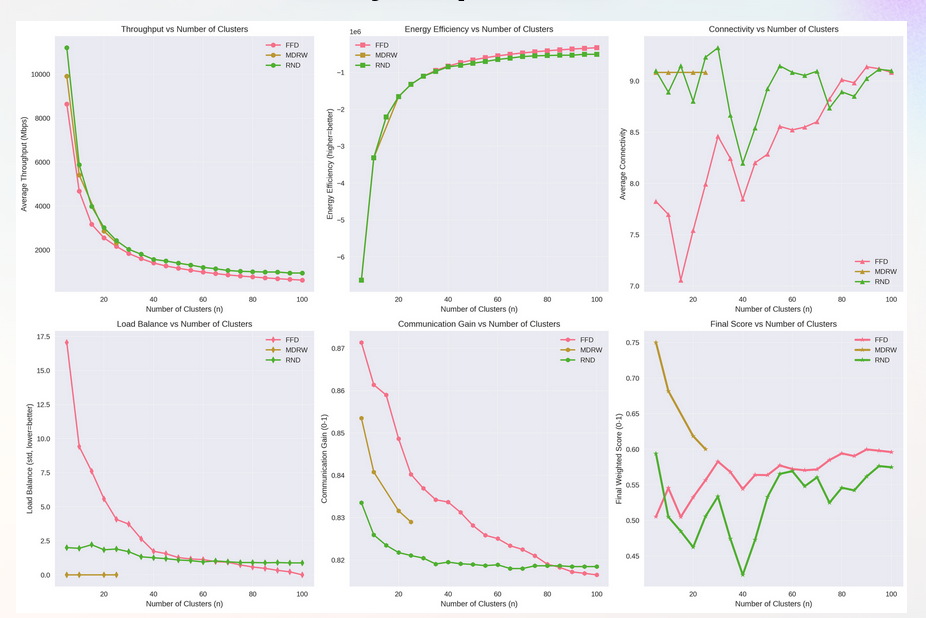

## Conclusion

Le cluster initial est très dense, avec de nombreux pics d'activité ce qui favorise les méthodes aléatoires, qui sont particulièrement efficaces sur ces pics.  

    Résultats comparatifs
Si nous comparons les résultats le DBSCAN obtient le meilleur score global, grâce à sa flexibilité sur le nombre de clusters.
Pour un nombre de clusters fixé à 10, la méthode MDRW est la plus efficace (selon notre pondération), mais elle présente une complexité algorithmique élevée.

En faisant varier le nombre de clusters :
La méthode MDRW reste performant mais elle est limité à 23 clusters maximum.
Si on exclue MDRW suite à cette limitation, la méthode FFD devient la meilleure alternative pour un nombre de clusters variable entre 1 et 100 en suivant notre pondération.

Ce que nous montre l'analyse des résultats comparatifs est qu'il faut adapter le choix de la méthode de clustering à notre problème, un nombre de cluster voulu, une consommation basse, un débit élevé ...
Dans l'ensemble, les méthodes testées sont globalement satisfaisantes même si des améliorations sont possibles, notamment sur la scalabilité et l’efficacité computationnelle des méthodes de clustering.
